# Experiment metrics from `logs/logs.json`

Loads logged runs and plots **metrics only**, labeled by **experiment name** (not id or model string).

In [7]:
from pathlib import Path

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def resolve_logs_path() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent):
        p = base / "logs" / "logs.json"
        if p.is_file():
            return p
    raise FileNotFoundError("logs/logs.json not found (run from repo root or notebooks/).")

LOG_PATH = resolve_logs_path()
with open(LOG_PATH, encoding="utf-8") as f:
    data = json.load(f)

rows = []
for exp in data.get("experiments", []):
    name = exp.get("name") or exp.get("id", "")
    metrics = exp.get("metrics") or {}
    row = {"name": name, **metrics}
    rows.append(row)

df = pd.DataFrame(rows)
metric_cols = [c for c in df.columns if c != "name"]
df = df.set_index("name")
df_metrics = df[metric_cols]
display(df_metrics)

,Recall@1,Recall@5,Recall@10,MRR
name,,,,
CLIP Retrieval,0.239,0.462,0.564,0.334
CLIP Retrieval | CLIP Reranker,0.244,0.469,0.573,0.340
CLIP Retrieval | LLM-QE,0.241,0.465,0.570,0.337
CLIP Retrieval | LLM-QE | CLIP Reranker,0.244,0.469,0.573,0.340
CLIP Retrieval | BLIP2 Captions Fusion,0.176,0.353,0.442,0.252
CLIP Retrieval | BLIP2 Captions Fusion | CLIP Reranking,0.241,0.455,0.549,0.332
CLIP Retrieval | LLM-QE | BLIP2 Captions Fusion | CLIP Reranking,0.240,0.452,0.544,0.330


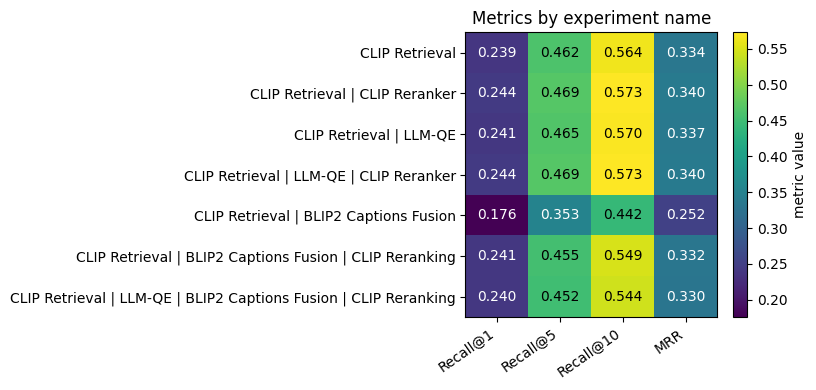

In [8]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * len(df_metrics))))
vals = df_metrics.to_numpy(dtype=float)
im = ax.imshow(vals, aspect="auto", cmap="viridis", vmin=vals.min(), vmax=vals.max())
ax.set_xticks(np.arange(len(df_metrics.columns)))
ax.set_xticklabels(df_metrics.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(df_metrics.index)))
ax.set_yticklabels(df_metrics.index)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v = vals[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", color="white" if v < (vals.min() + vals.max()) / 2 else "black")
ax.set_title("Metrics by experiment name")
fig.colorbar(im, ax=ax, label="metric value")
plt.tight_layout()
plt.show()

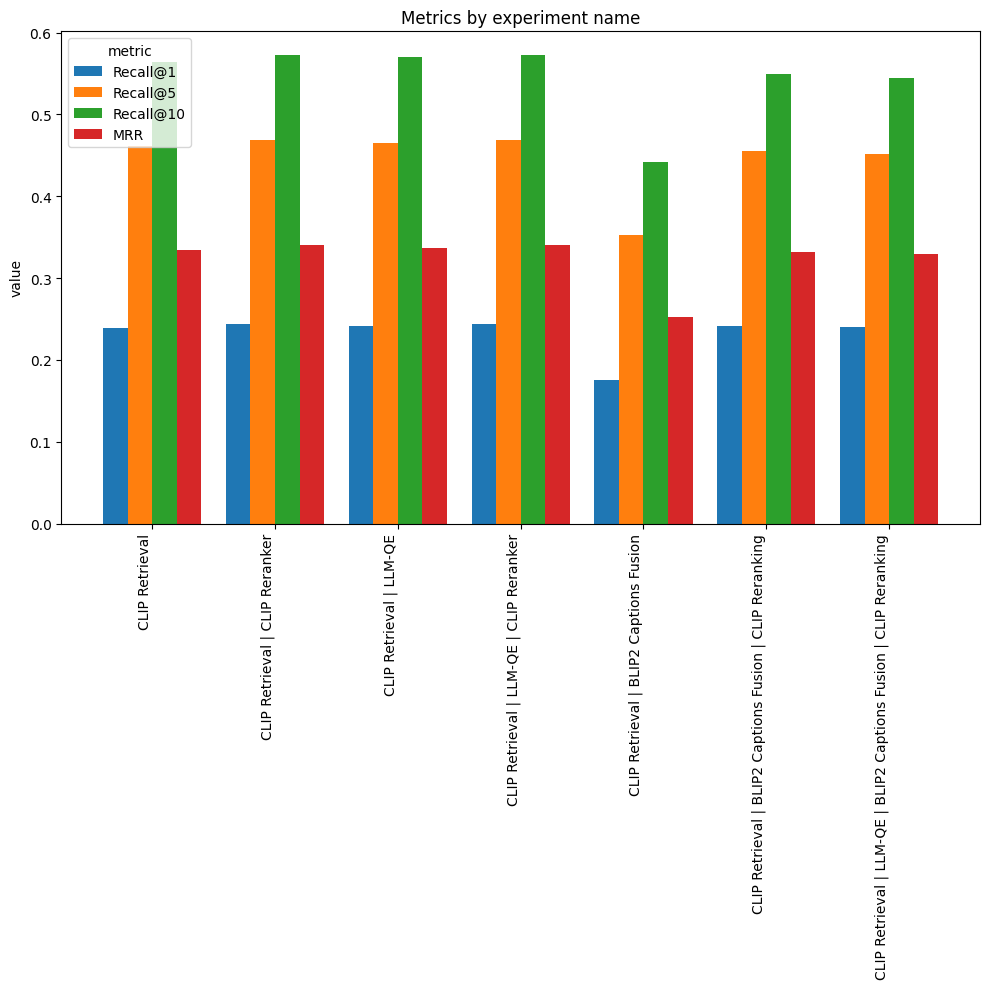

In [17]:
names = df_metrics.index.tolist()
metrics_list = df_metrics.columns.tolist()
x = np.arange(len(names))
width = 0.8 / len(metrics_list)
fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(names)), 10))
for k, col in enumerate(metrics_list):
    ax.bar(
        x + (k - (len(metrics_list) - 1) / 2) * width,
        df_metrics[col].to_numpy(),
        width,
        label=col,
    )
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=90, ha="right")
ax.set_ylabel("value")
ax.set_title("Metrics by experiment name")
ax.legend(title="metric", loc="upper left")
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

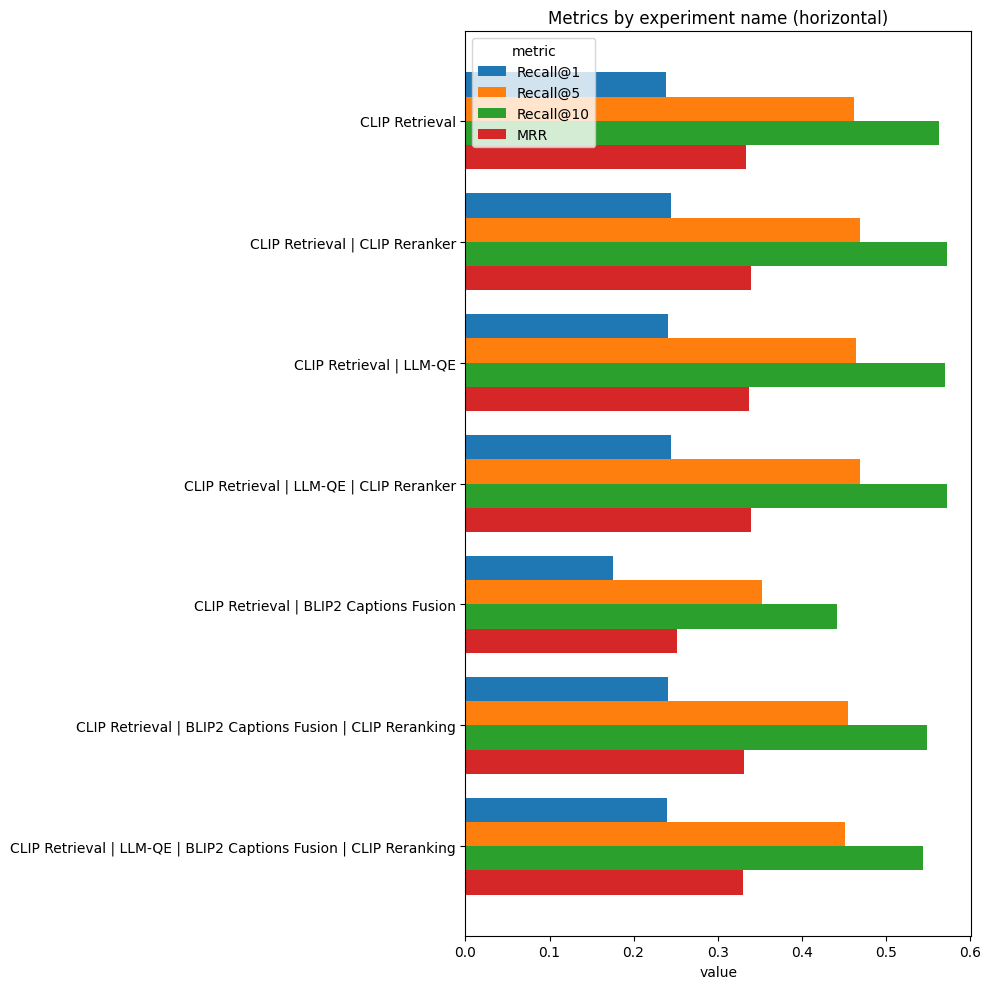

In [14]:
names = df_metrics.index.tolist()
metrics_list = df_metrics.columns.tolist()
y = np.arange(len(names))
width = 0.8 / len(metrics_list)
fig, ax = plt.subplots(figsize=(10, max(10, 0.5 * len(names))))
for k, col in enumerate(metrics_list):
    ax.barh(y + (k - (len(metrics_list) - 1) / 2) * width, df_metrics[col], width, label=col)
ax.set_yticks(y)
ax.set_yticklabels(names)
ax.set_xlabel("value")
ax.set_title("Metrics by experiment name (horizontal)")
ax.legend(title="metric", loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

/var/folders/g2/9_y7bfxs4l7clq4gyjjn2_5m0000gn/T/ipykernel_96780/2246563904.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


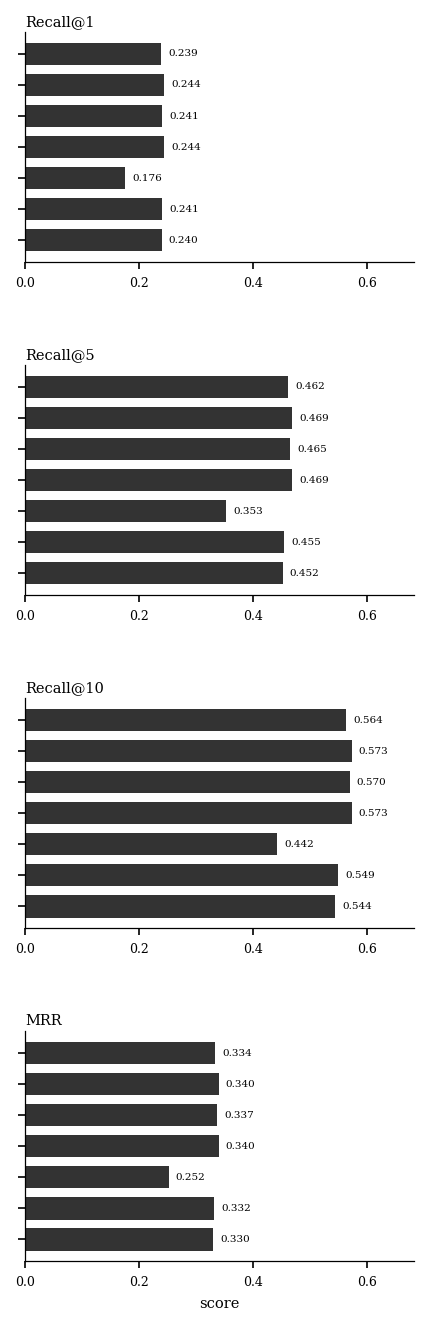

In [19]:
import textwrap

# ~IEEE/ACM single-column width (inches); adjust to your template
SINGLE_COL_W_IN = 3.35

pub_rc = {
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 5.5,
    "axes.linewidth": 0.6,
    "lines.linewidth": 0.8,
}

names = df_metrics.index.tolist()
metrics_list = list(df_metrics.columns)
y = np.arange(len(names))
# Wrap labels so they fit a narrow column (lower `width` = narrower figure-friendly)
wrapped = ["\n".join(textwrap.wrap(str(n), width=18)) for n in names]

with plt.rc_context(pub_rc):
    nrows = len(metrics_list)
    fig_h = max(2.8, 0.38 * len(names) * nrows)
    fig, axes = plt.subplots(
        nrows,
        1,
        sharey=True,
        figsize=(SINGLE_COL_W_IN, fig_h),
        gridspec_kw={"hspace": 0.45},
    )
    if nrows == 1:
        axes = [axes]
    xmax = float(df_metrics.to_numpy().max()) * 1.14 + 0.03
    xpad = xmax * 0.018
    for ax, col in zip(axes, metrics_list):
        vals = df_metrics[col].to_numpy()
        ax.barh(y, vals, height=0.72, color=".2")
        for yi, v in zip(y, vals):
            ax.text(v + xpad, yi, f"{v:.3f}", va="center", ha="left", fontsize=5)
        ax.set_title(col, loc="left", pad=3)
        ax.set_xlim(0, xmax)
        ax.tick_params(axis="y", labelleft=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(wrapped)
    axes[0].invert_yaxis()
    axes[-1].set_xlabel("score")
    fig.align_xlabels(axes)

plt.tight_layout()
plt.show()

# Uncomment to export for LaTeX (vector):
# fig.savefig("metrics_single_column.pdf", bbox_inches="tight", pad_inches=0.02)